In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp

import numpy as np
import matplotlib.pyplot as plt
from dmri.simulators import Ball, Stick, Zeppelin, Dti, BallStick, Ball2Stick, Sphere, Cylinder, SandiB, SandiW, BallStickSharedDiffusivity, Ball3StickSharedDiffusivity
from dmri.simulators.acquisition_scheme import acquisition_scheme
from dmri.simulators import WatsonStick, WatsonZeppelin,BinghamStick, BinghamZeppelin, NoddiW, NoddiB


In [3]:
bvals = jnp.linspace(0, 3000, 100)
bvecs = np.random.randn(100, 3)
bvecs = bvecs / np.linalg.norm(bvecs, axis=1)[:, None]

acq = acquisition_scheme(bvals, bvecs)


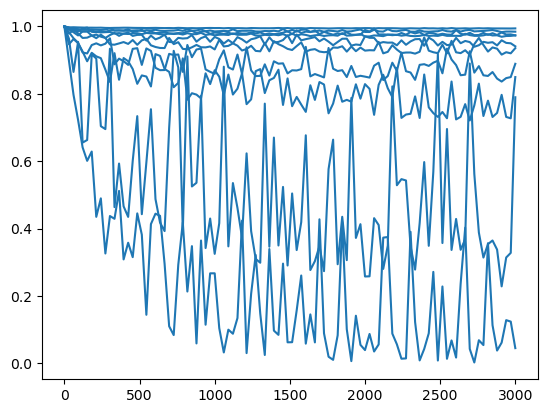

In [8]:
from dmri.simulators.local_signal_models.ball import MultiShellBall
from dmri.simulators.local_signal_models.stick import MultiShellStick
from dmri.simulators.multi_compartment import MultiShellBall3StickSharedDiffusivity, MultiShellBall3StickSharedDiffusivityUniformFraction

def sim(theta):
    return MultiShellBall3StickSharedDiffusivityUniformFraction.from_theta(theta).signal(acq)

signals = jax.vmap(sim)(np.random.randn(10, MultiShellBall3StickSharedDiffusivityUniformFraction.theta_dim))

_ = plt.plot(bvals, signals.T, color="C0", alpha=1.)


(array([  0.,   0.,   0.,   0.,   0., 100.,   0.,   0.,   0.,   0.]),
 array([-0.5       , -0.40000001, -0.30000001, -0.19999999, -0.09999999,
         0.        ,  0.10000002,  0.19999999,  0.30000001,  0.40000004,
         0.5       ]),
 <BarContainer object of 10 artists>)

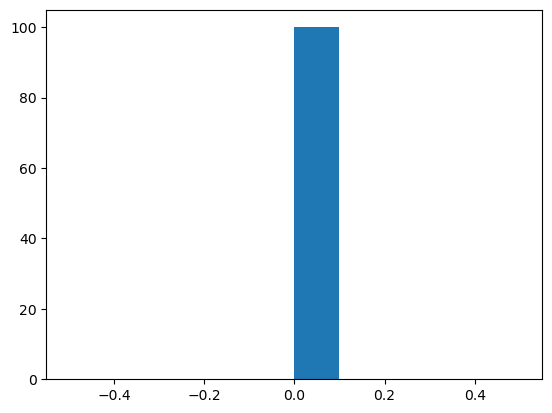

In [24]:
plt.hist(jax.random.gamma(jax.random.key(0), 0.00001, (100,))/0.0005)

In [13]:
import scipy

scipy.stats.gamma.rvs(0.005, size=(100,))

array([8.02030213e-063, 2.39186537e-056, 9.80142416e-002, 4.86877732e-041,
       2.43358933e-123, 2.28585219e-102, 1.87925288e-006, 2.36489665e-237,
       1.38366939e-075, 2.25538265e-023, 3.24652594e-041, 3.07029262e-051,
       5.22128741e-013, 1.33844281e-237, 2.63297958e-028, 1.10271215e-033,
       9.28685823e-063, 1.94119276e-044, 5.80402692e-125, 1.43460063e-089,
       8.57775338e-030, 1.73087166e-090, 1.08410601e-106, 5.65710803e-068,
       3.13137845e-052, 0.00000000e+000, 1.37144552e-110, 7.70348656e-048,
       6.14407778e-088, 1.27728818e-006, 1.21444674e-168, 5.58163703e-073,
       3.82634774e-015, 1.36420729e-083, 7.18338496e-004, 1.04771345e-062,
       4.24361079e-139, 3.45659378e-005, 4.75191513e-020, 1.75064189e-006,
       1.22832273e-023, 9.53260039e-028, 5.29747169e-017, 1.43185041e-202,
       7.24769128e-118, 2.40836463e-029, 1.11345236e-206, 4.15737231e-034,
       2.15797818e-004, 1.32642492e-165, 5.48551882e-029, 1.15311542e-100,
       1.25928747e-006, 1

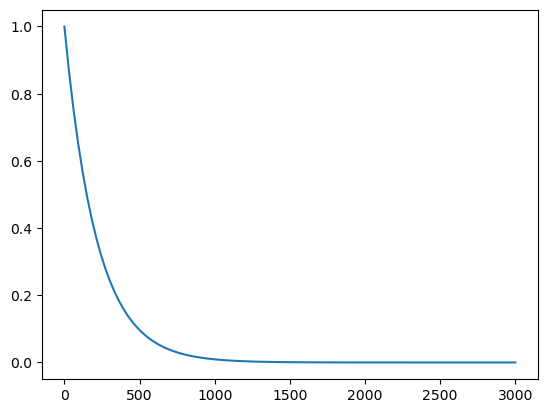

In [4]:
theta = np.random.randn(Ball.theta_dim)
ball = Ball.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

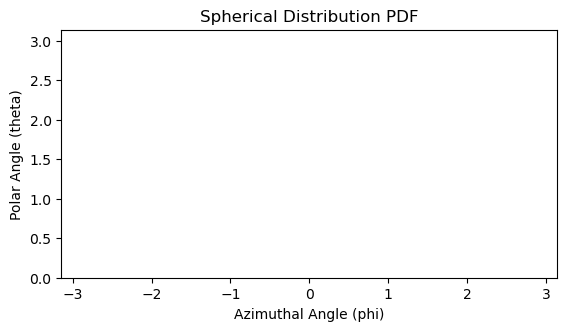

In [5]:

%matplotlib inline
ball.to_fod().viz()

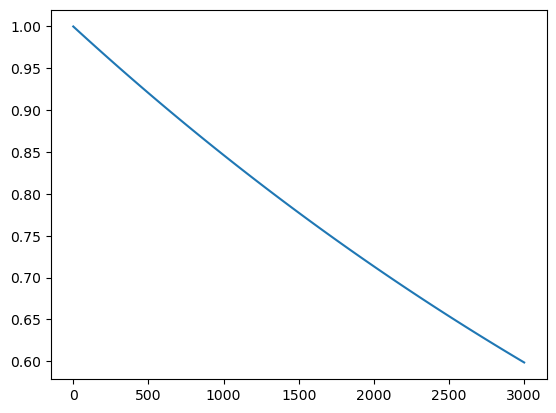

In [6]:
theta = np.random.randn(Sphere.theta_dim)
ball = Sphere.from_theta(theta)


signal = ball.signal(acq)

plt.plot(bvals, signal)

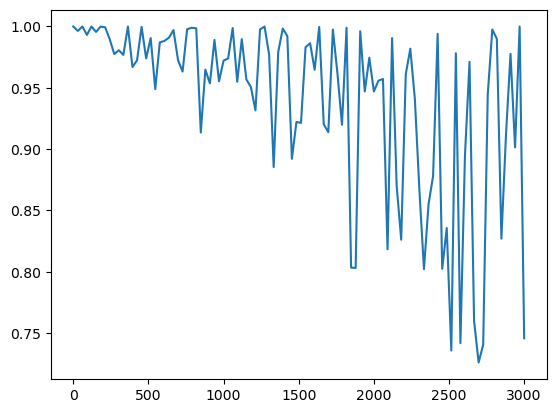

In [7]:
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)


signal = stick.signal(acq)

plt.plot(bvals, signal)

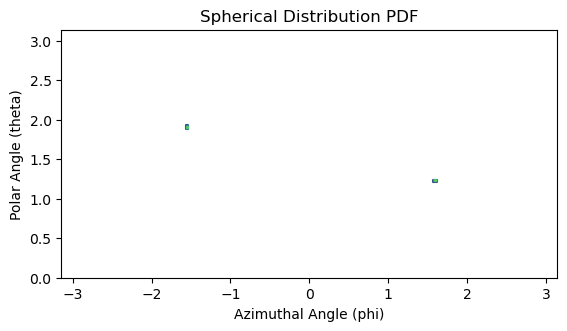

In [8]:
%matplotlib inline
theta = np.random.randn(Stick.theta_dim)
stick = Stick.from_theta(theta)
stick.to_fod().viz(plot_type='polar')

In [9]:
def stick_mu_samples(thetas):
    stick = Stick.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

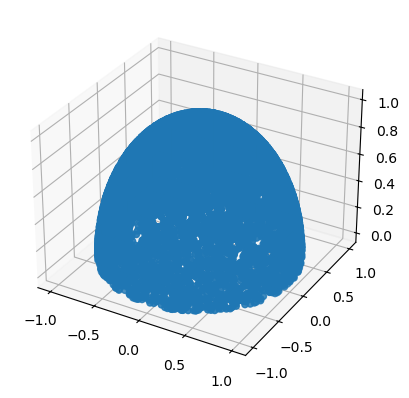

In [10]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(10000, Stick.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

In [12]:
# theta = np.random.randn(Cylinder.theta_dim)
# stick = Cylinder.from_theta(theta)


# signal = stick.signal(acq)

# plt.plot(bvals, signal)

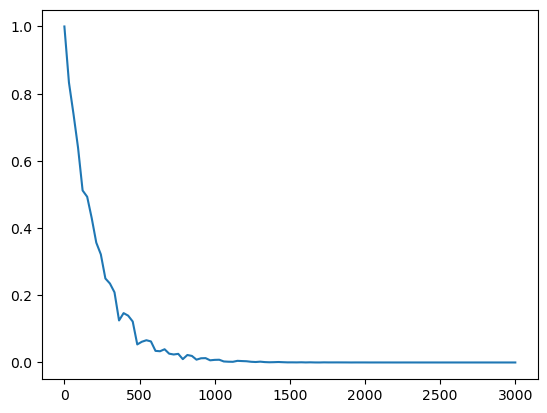

In [29]:
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)


signal = zep.signal(acq)

plt.plot(bvals, signal)

In [64]:
def stick_mu_samples(thetas):
    stick = Zeppelin.from_theta(thetas)
    mu = stick.mu
    # Convert to cartesian
    mu = jnp.array([jnp.sin(mu[0]) * jnp.cos(mu[1]), jnp.sin(mu[0]) * jnp.sin(mu[1]), jnp.cos(mu[0])])
    return mu

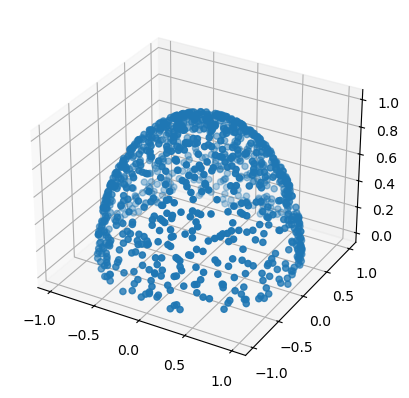

In [13]:
pos = jax.vmap(stick_mu_samples)(np.random.randn(1000, Zeppelin.theta_dim))
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2])

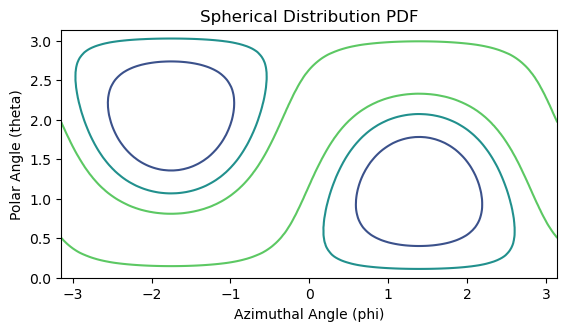

In [14]:
%matplotlib inline
theta = np.random.randn(Zeppelin.theta_dim)
zep = Zeppelin.from_theta(theta)
zep.to_fod().viz()

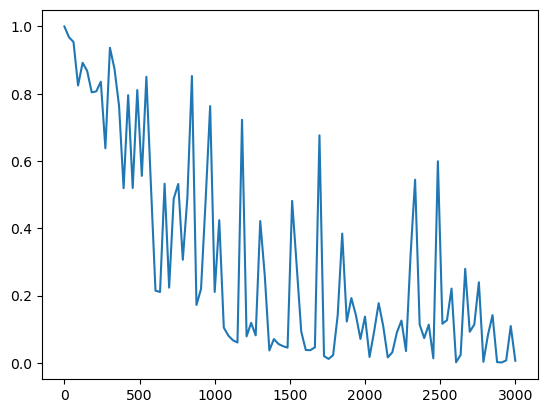

In [15]:
theta = np.random.randn(Dti.theta_dim)
dti = Dti.from_theta(theta)


signal = dti.signal(acq)

plt.plot(bvals, signal)

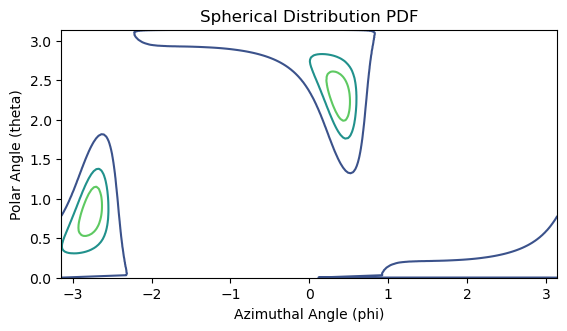

In [16]:
%matplotlib inline
dti.to_fod().viz()

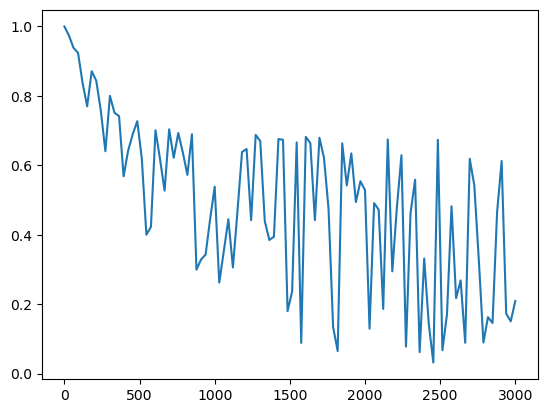

In [14]:
ball_stick = BallStick.from_theta(np.random.randn(BallStick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

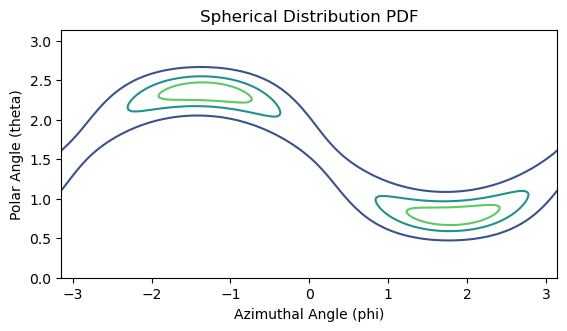

In [15]:
%matplotlib inline
dti.to_fod().viz()

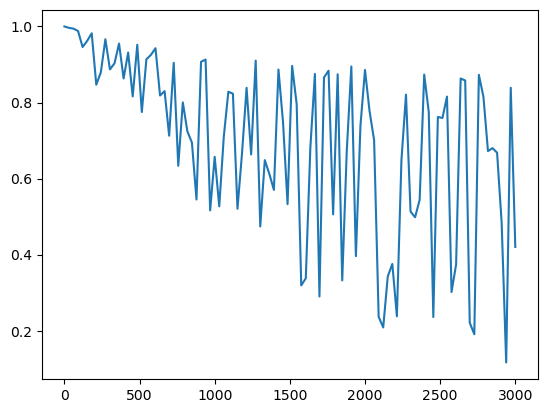

In [28]:
ball_stick_constrained = Ball3StickSharedDiffusivity.from_theta(np.random.randn(Ball3StickSharedDiffusivity.theta_dim))
signal = ball_stick_constrained.signal(acq)

plt.plot(bvals, signal)

In [ ]:
ball_stick_constrained.model_compartments[1].lam_par

Array(0.00963822, dtype=float32)

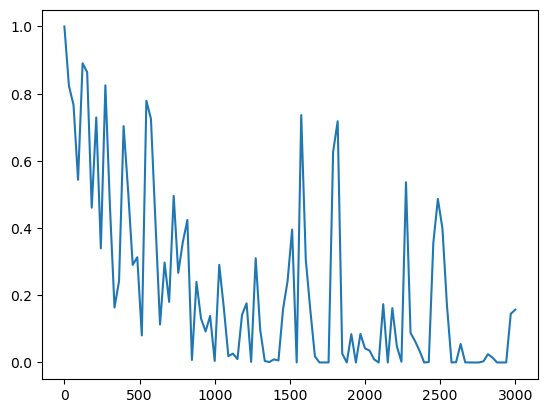

In [16]:
ball_stick = Ball2Stick.from_theta(np.random.randn(Ball2Stick.theta_dim))

signal = ball_stick.signal(acq, None)

plt.plot(bvals, signal)

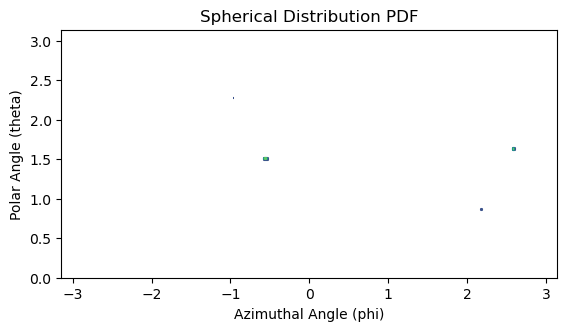

In [17]:
%matplotlib inline
ball_stick.to_fod().viz()

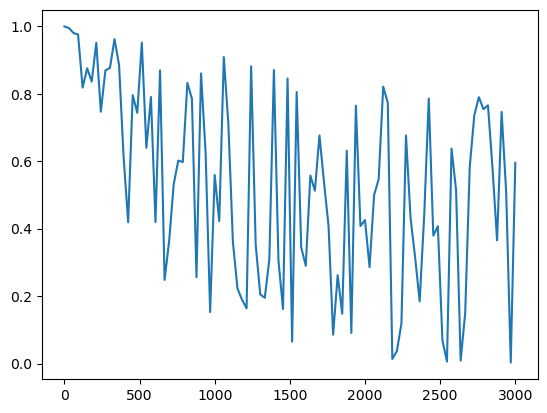

In [18]:
racket = WatsonStick.from_theta(np.random.randn(WatsonStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

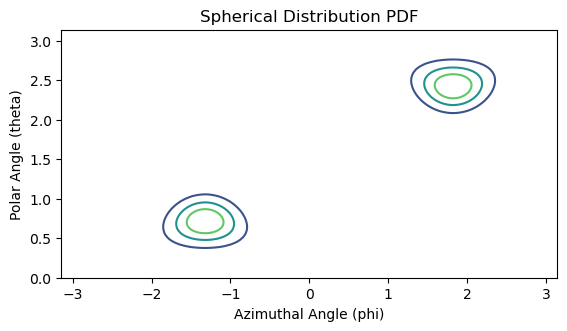

In [19]:
%matplotlib inline
racket.to_fod().viz()

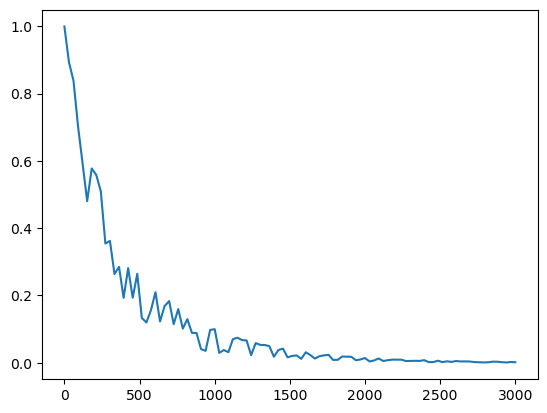

In [20]:
racket2 = WatsonZeppelin.from_theta(np.random.randn(WatsonZeppelin.theta_dim))
signal = racket2.signal(acq)
plt.plot(bvals, signal)

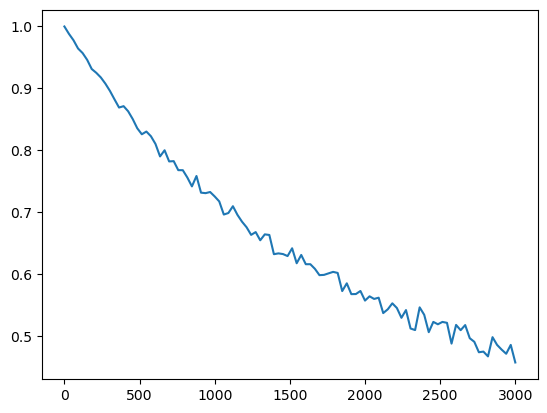

In [21]:
bracket = BinghamStick.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = bracket.signal(acq)
plt.plot(bvals, signal)

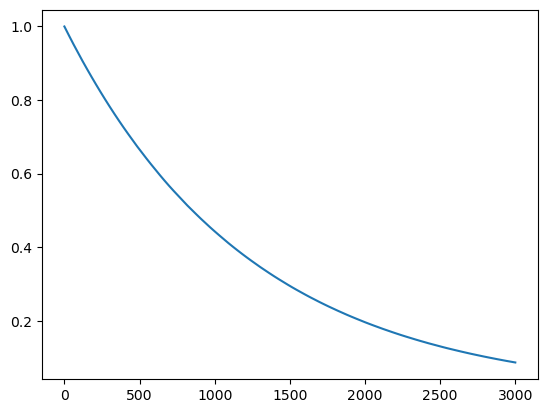

In [22]:
racket = BinghamZeppelin.from_theta(np.random.randn(BinghamStick.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

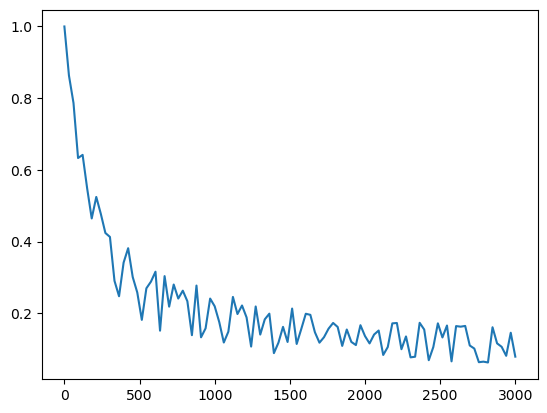

In [23]:
racket = NoddiW.from_theta(np.random.randn(NoddiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

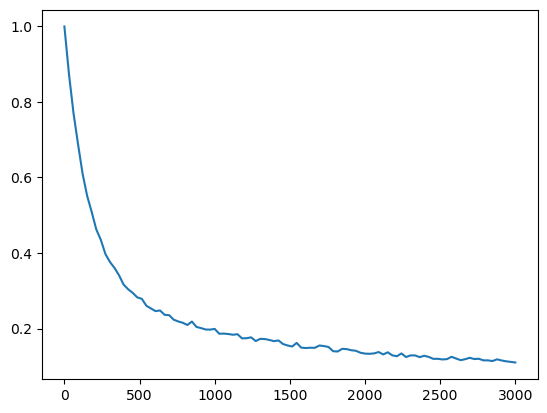

In [24]:
racket = NoddiB.from_theta(np.random.randn(NoddiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

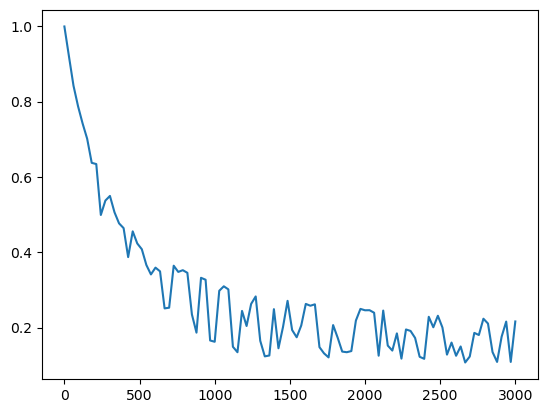

In [25]:
racket = SandiW.from_theta(np.random.randn(SandiW.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)

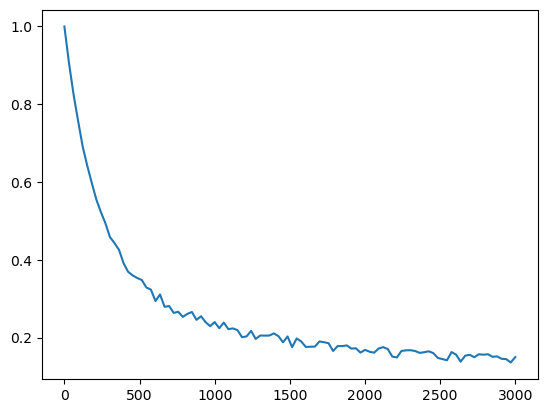

In [26]:
racket = SandiB.from_theta(np.random.randn(SandiB.theta_dim))
signal = racket.signal(acq)
plt.plot(bvals, signal)